In [63]:
import numpy as np
import scipy as sp

import matplotlib.pyplot as plt
from scipy.stats import binom

In [64]:
hydrated_farm_land = 0
unhydrated_farm_land = 0
adjacent_same = False
random_tick_rate = 3 / 16 ** 3
sides = 2

hydration_factor = 1+3+(3*hydrated_farm_land+1*unhydrated_farm_land)/4
scaled_hydration_factor = hydration_factor * (0.5 if adjacent_same else 1)
growth_chance_per_random_tick = 1/(int(25 / scaled_hydration_factor)+1)/4
growth_chance_per_tick = growth_chance_per_random_tick * random_tick_rate

print(growth_chance_per_random_tick)
print(growth_chance_per_tick)

0.03571428571428571
2.6157924107142856e-05


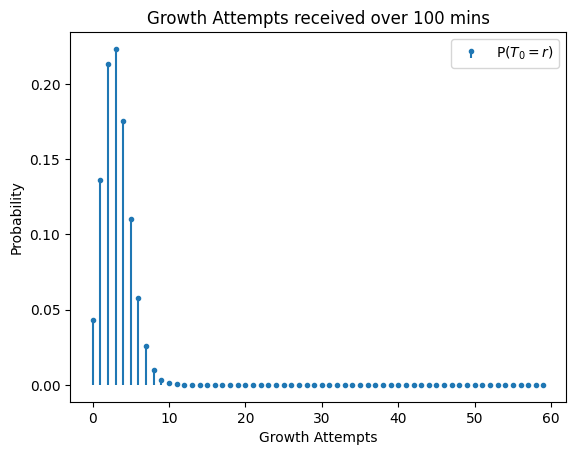

In [65]:
def first_check():
    minutes = 100
    total_time_gt = 20*60*minutes
    T_0_dist = binom(total_time_gt, growth_chance_per_tick)
    random_ticks = np.arange(0, 60)
    T_0 = T_0_dist.pmf(random_ticks)
    plt.stem(random_ticks, T_0, markerfmt='.', basefmt=' ')
    plt.legend([r'P$(T_0 = r)$'])
    plt.xlabel("Growth Attempts")
    plt.ylabel("Probability")
    plt.title(f"Growth Attempts received over {minutes} mins")
    plt.show()

first_check()

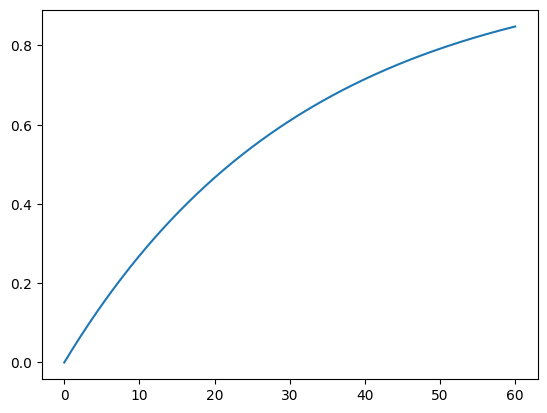

In [66]:
limit = 60 * 60 * 20
times = np.arange(limit)
expected_growth = 1- binom.cdf(0, times, growth_chance_per_tick)

plt.plot(times/60/20, expected_growth)
plt.show()

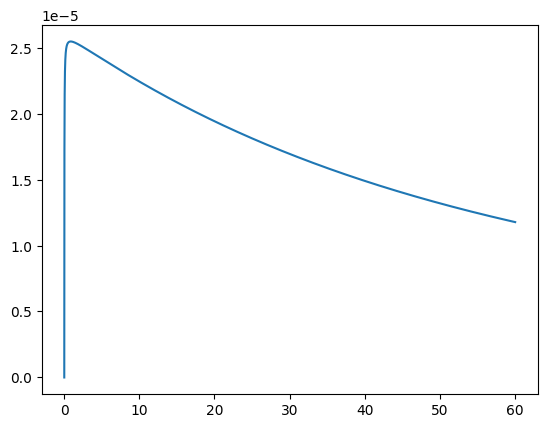

In [67]:
overhead = 14
rates = expected_growth / (times + overhead)

plt.plot((times + overhead)/60/20, rates)
plt.show()